# 💳 Credit Card Fraud Detection — Production ML Pipeline
**Stack:** XGBoost · Scikit-learn Pipelines · SMOTE · MLflow · Optuna

**Goal:** Build a production-ready fraud detection model with proper ML practices:
- No data leakage (preprocessing inside Pipeline)
- Handle class imbalance with SMOTE
- Compare models properly (Precision-Recall AUC, not accuracy)
- Track all experiments with MLflow
- Export best model as model.pkl for FastAPI deployment

In [17]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "No GPU found — make sure Kaggle GPU is enabled in Settings")
 

Wed May 13 03:35:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Cell 1 — Install Dependencies

In [18]:
!pip install -q xgboost imbalanced-learn mlflow optuna shap

## Cell 2 — Imports

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import mlflow
import mlflow.sklearn
import optuna
import shap
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, roc_auc_score,
    precision_recall_curve, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

RANDOM_STATE = 42
print('All imports successful ✅')

All imports successful ✅


## Cell 3 — Load Data

In [20]:
# On Kaggle: dataset is at /kaggle/input/creditcardfraud/creditcard.csv
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

print(f'Shape: {df.shape}')
print(f'\nClass Distribution:')
print(df['Class'].value_counts())
print(f'\nFraud rate: {df["Class"].mean()*100:.4f}%')
print(f'\nNull values: {df.isnull().sum().sum()}')
df.head()

Shape: (284807, 31)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%

Null values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Cell 4 — EDA

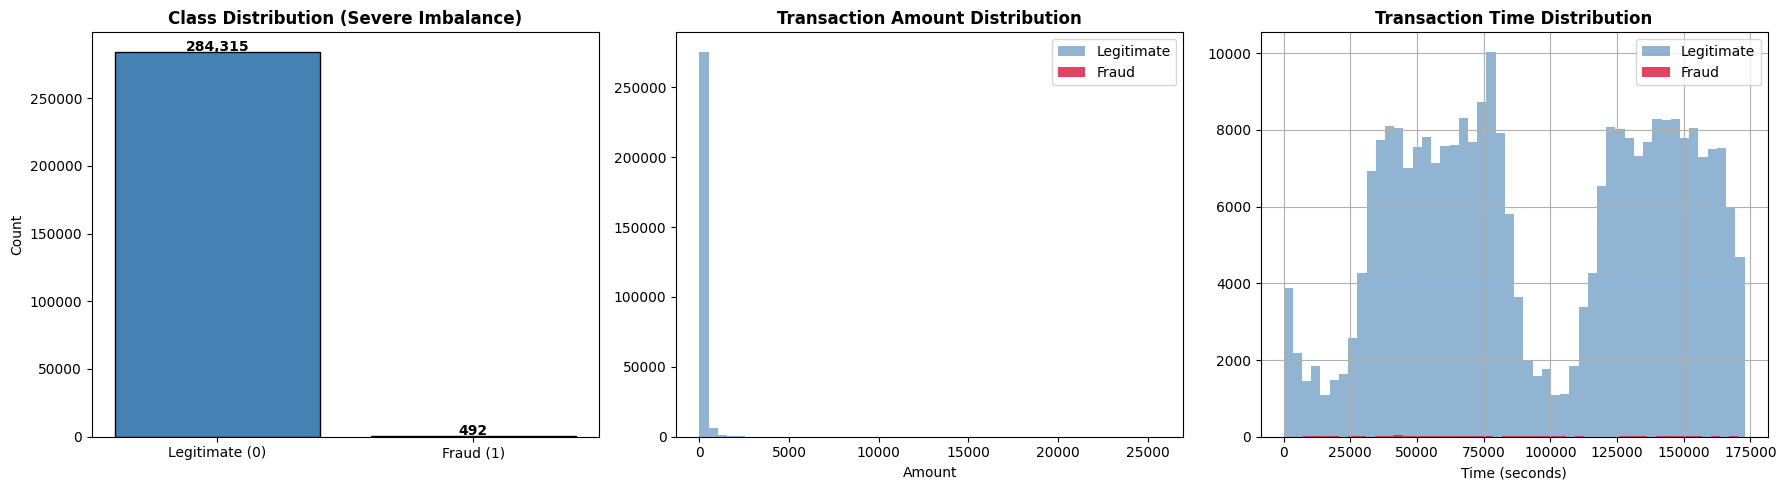


Key Insight: 99.83% legitimate vs 0.17% fraud — SMOTE is essential


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class imbalance
class_counts = df['Class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values,
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Distribution (Severe Imbalance)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Transaction amount by class — FIX: plot each class separately
axes[1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6,
             color='steelblue', label='Legitimate')
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.8,
             color='crimson', label='Fraud')
axes[1].set_title('Transaction Amount Distribution', fontweight='bold')
axes[1].set_xlabel('Amount')
axes[1].legend()

# Time distribution
df[df['Class']==0]['Time'].hist(bins=50, ax=axes[2], alpha=0.6,
                                 color='steelblue', label='Legitimate')
df[df['Class']==1]['Time'].hist(bins=50, ax=axes[2], alpha=0.8,
                                 color='crimson', label='Fraud')
axes[2].set_title('Transaction Time Distribution', fontweight='bold')
axes[2].set_xlabel('Time (seconds)')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nKey Insight: 99.83% legitimate vs 0.17% fraud — SMOTE is essential')

## Cell 5 — Feature Engineering & Train/Test Split

In [22]:
# Feature engineering
# Log-transform Amount to reduce skewness
df['Amount_log'] = np.log1p(df['Amount'])

# Time-based features (hour of day pattern)
df['Hour'] = (df['Time'] // 3600) % 24

# Drop original Amount and Time (replaced by engineered features)
features_to_drop = ['Time', 'Amount', 'Class']
X = df.drop(columns=features_to_drop)
y = df['Class']

print(f'Features: {X.shape[1]}')
print(f'Feature names: {list(X.columns)}')

# Stratified split — preserves fraud ratio in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # CRITICAL for imbalanced data
    random_state=RANDOM_STATE
)

print(f'\nTrain size: {X_train.shape[0]:,} | Fraud in train: {y_train.sum()}')
print(f'Test size:  {X_test.shape[0]:,} | Fraud in test:  {y_test.sum()}')
print('\n✅ Stratified split done — fraud ratio preserved')

Features: 30
Feature names: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log', 'Hour']

Train size: 227,845 | Fraud in train: 394
Test size:  56,962 | Fraud in test:  98

✅ Stratified split done — fraud ratio preserved


## Cell 6 — Build Pipelines (No Leakage)

In [23]:
# WHY ImbPipeline?
# SMOTE must ONLY be applied to training data.
# Putting it inside the pipeline guarantees it never touches test data.
# This prevents data leakage — a common mistake in fraud detection.

pipelines = {
    'LogisticRegression': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.3)),
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),

    'RandomForest': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.3)),
        ('model', RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    'XGBoost': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.3)),
        ('model', XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            scale_pos_weight=577,   # ratio of negative/positive class
            eval_metric='aucpr',
            device='cuda',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

print('Pipelines built ✅')
print('\nWhy these metrics matter for fraud:')
print('  - Accuracy is USELESS (99% accuracy by predicting all legit)')
print('  - Precision-Recall AUC (PR-AUC) is the gold standard')
print('  - ROC-AUC is secondary')
print('  - F1 Score for threshold-specific performance')

Pipelines built ✅

Why these metrics matter for fraud:
  - Accuracy is USELESS (99% accuracy by predicting all legit)
  - Precision-Recall AUC (PR-AUC) is the gold standard
  - ROC-AUC is secondary
  - F1 Score for threshold-specific performance


## Cell 7 — MLflow Experiment Tracking + Model Comparison

In [24]:
mlflow.set_experiment('fraud_detection_baseline')

results = {}

for name, pipeline in pipelines.items():
    print(f'\nTraining {name}...')

    with mlflow.start_run(run_name=name):
        # Train
        pipeline.fit(X_train, y_train)

        # Predict
        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)[:, 1]

        # Metrics
        pr_auc  = average_precision_score(y_test, y_prob)
        roc_auc = roc_auc_score(y_test, y_prob)
        report  = classification_report(y_test, y_pred, output_dict=True)
        f1_fraud = report['1']['f1-score']
        precision_fraud = report['1']['precision']
        recall_fraud = report['1']['recall']

        # Log to MLflow
        mlflow.log_param('model_type', name)
        mlflow.log_param('smote_strategy', 0.3)
        mlflow.log_metric('pr_auc', pr_auc)
        mlflow.log_metric('roc_auc', roc_auc)
        mlflow.log_metric('f1_fraud', f1_fraud)
        mlflow.log_metric('precision_fraud', precision_fraud)
        mlflow.log_metric('recall_fraud', recall_fraud)
        mlflow.sklearn.log_model(pipeline, artifact_path='model')

        results[name] = {
            'pipeline': pipeline,
            'pr_auc': pr_auc,
            'roc_auc': roc_auc,
            'f1_fraud': f1_fraud,
            'precision_fraud': precision_fraud,
            'recall_fraud': recall_fraud,
            'y_prob': y_prob,
            'y_pred': y_pred
        }

        print(f'  PR-AUC:    {pr_auc:.4f}')
        print(f'  ROC-AUC:   {roc_auc:.4f}')
        print(f'  F1 (Fraud):{f1_fraud:.4f}')

# Summary table
print('\n' + '='*60)
print('MODEL COMPARISON SUMMARY')
print('='*60)
summary_df = pd.DataFrame({
    name: {
        'PR-AUC': f"{v['pr_auc']:.4f}",
        'ROC-AUC': f"{v['roc_auc']:.4f}",
        'F1-Fraud': f"{v['f1_fraud']:.4f}",
        'Precision': f"{v['precision_fraud']:.4f}",
        'Recall': f"{v['recall_fraud']:.4f}"
    }
    for name, v in results.items()
}).T
print(summary_df)


Training LogisticRegression...


2026/05/13 03:35:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 03:35:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  PR-AUC:    0.7188
  ROC-AUC:   0.9714
  F1 (Fraud):0.1042

Training RandomForest...


2026/05/13 03:37:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 03:37:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  PR-AUC:    0.8626
  ROC-AUC:   0.9648
  F1 (Fraud):0.8421

Training XGBoost...


2026/05/13 03:37:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 03:37:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  PR-AUC:    0.7867
  ROC-AUC:   0.9841
  F1 (Fraud):0.1371

MODEL COMPARISON SUMMARY
                    PR-AUC ROC-AUC F1-Fraud Precision  Recall
LogisticRegression  0.7188  0.9714   0.1042    0.0552  0.9184
RandomForest        0.8626  0.9648   0.8421    0.8696  0.8163
XGBoost             0.7867  0.9841   0.1371    0.0742  0.9082


## Cell 8 — Hyperparameter Tuning with Optuna (Best Model)

In [25]:
# Tune XGBoost (expected best model) with Optuna
def objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'max_depth':       trial.suggest_int('max_depth', 3, 9),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':trial.suggest_int('min_child_weight', 1, 10),
        'gamma':           trial.suggest_float('gamma', 0, 5),
    }

    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.3)),
        ('model', XGBClassifier(
            **params,
            scale_pos_weight=577,
            eval_metric='aucpr',
            device='cuda',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    # Stratified CV on training data only
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv, scoring='average_precision', n_jobs=-1
    )
    return scores.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\nBest PR-AUC (CV): {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [03:38:05] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [03:38:06] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the devic


Best PR-AUC (CV): 0.8437
Best params: {'n_estimators': 487, 'max_depth': 7, 'learning_rate': 0.13784453509479905, 'subsample': 0.6611738346597663, 'colsample_bytree': 0.7903458219139894, 'min_child_weight': 4, 'gamma': 2.251091002337847}


## Cell 9 — Train Final Tuned Model + Log to MLflow

In [26]:
best_params = study.best_params

final_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.3)),
    ('model', XGBClassifier(
        **best_params,
        scale_pos_weight=577,
        eval_metric='aucpr',
        device='cuda',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

mlflow.set_experiment('fraud_detection_baseline')

with mlflow.start_run(run_name='XGBoost_Optuna_Tuned'):
    final_pipeline.fit(X_train, y_train)

    y_pred_final = final_pipeline.predict(X_test)
    y_prob_final = final_pipeline.predict_proba(X_test)[:, 1]

    pr_auc_final  = average_precision_score(y_test, y_prob_final)
    roc_auc_final = roc_auc_score(y_test, y_prob_final)

    mlflow.log_params(best_params)
    mlflow.log_param('tuning', 'optuna_30_trials')
    mlflow.log_metric('pr_auc', pr_auc_final)
    mlflow.log_metric('roc_auc', roc_auc_final)
    mlflow.sklearn.log_model(final_pipeline, artifact_path='final_model')

    print(f'Final Tuned XGBoost Results:')
    print(f'  PR-AUC:  {pr_auc_final:.4f}')
    print(f'  ROC-AUC: {roc_auc_final:.4f}')
    print()
    print(classification_report(y_test, y_pred_final, target_names=['Legit', 'Fraud']))

2026/05/13 03:40:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 03:40:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Final Tuned XGBoost Results:
  PR-AUC:  0.8746
  ROC-AUC: 0.9838

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.55      0.88      0.67        98

    accuracy                           1.00     56962
   macro avg       0.77      0.94      0.84     56962
weighted avg       1.00      1.00      1.00     56962



## Cell 10 — Evaluation Plots

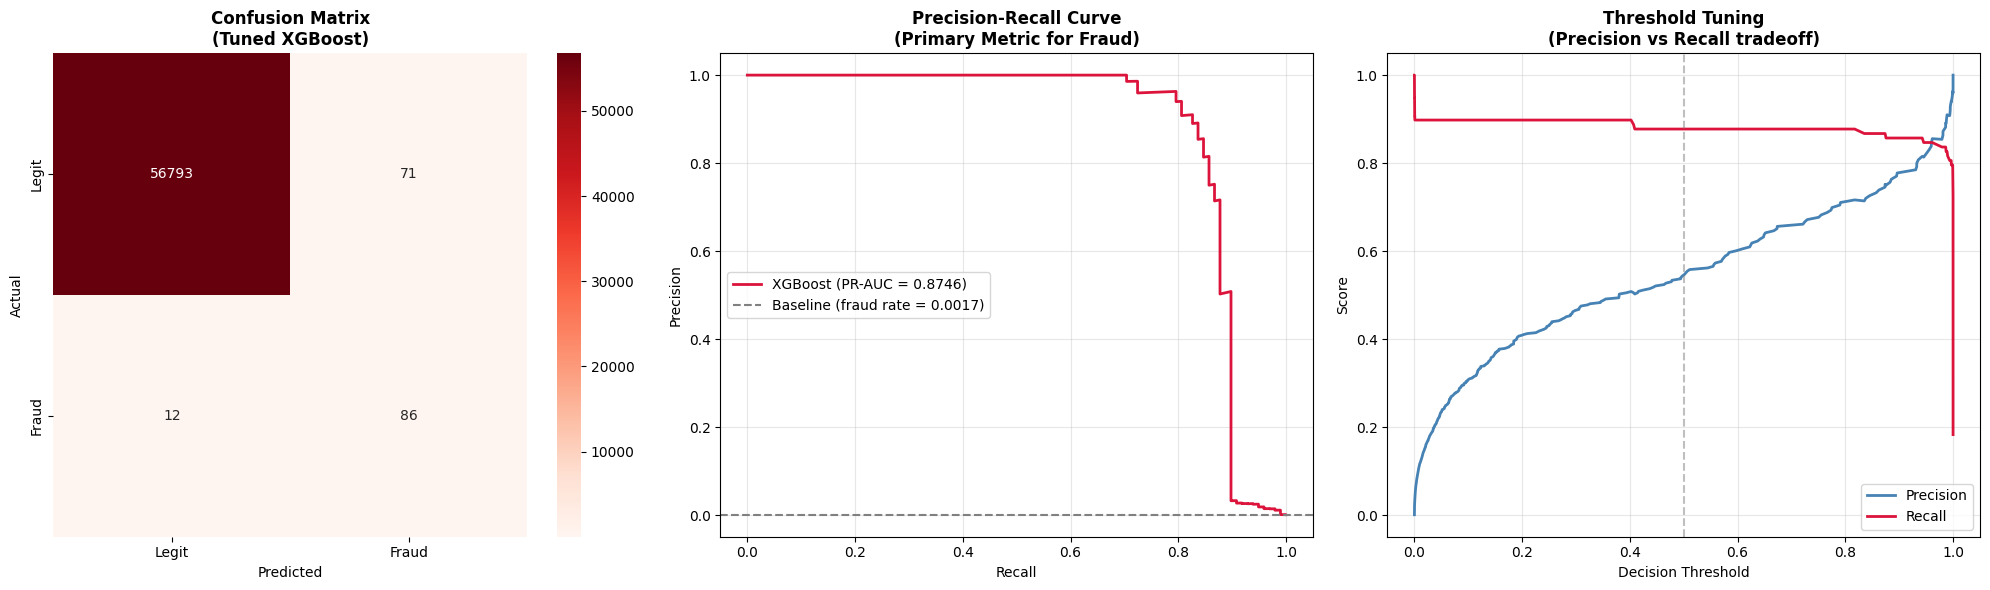

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
axes[0].set_title('Confusion Matrix\n(Tuned XGBoost)', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 2. Precision-Recall Curve (THE key curve for fraud)
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_final)
axes[1].plot(recall, precision, color='crimson', lw=2,
             label=f'XGBoost (PR-AUC = {pr_auc_final:.4f})')
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--',
                label=f'Baseline (fraud rate = {y_test.mean():.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve\n(Primary Metric for Fraud)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Threshold vs Precision/Recall tradeoff
axes[2].plot(thresholds, precision[:-1], color='steelblue', lw=2, label='Precision')
axes[2].plot(thresholds, recall[:-1], color='crimson', lw=2, label='Recall')
axes[2].set_xlabel('Decision Threshold')
axes[2].set_ylabel('Score')
axes[2].set_title('Threshold Tuning\n(Precision vs Recall tradeoff)', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default=0.5')

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 11 — SHAP Feature Importance (Explainability)

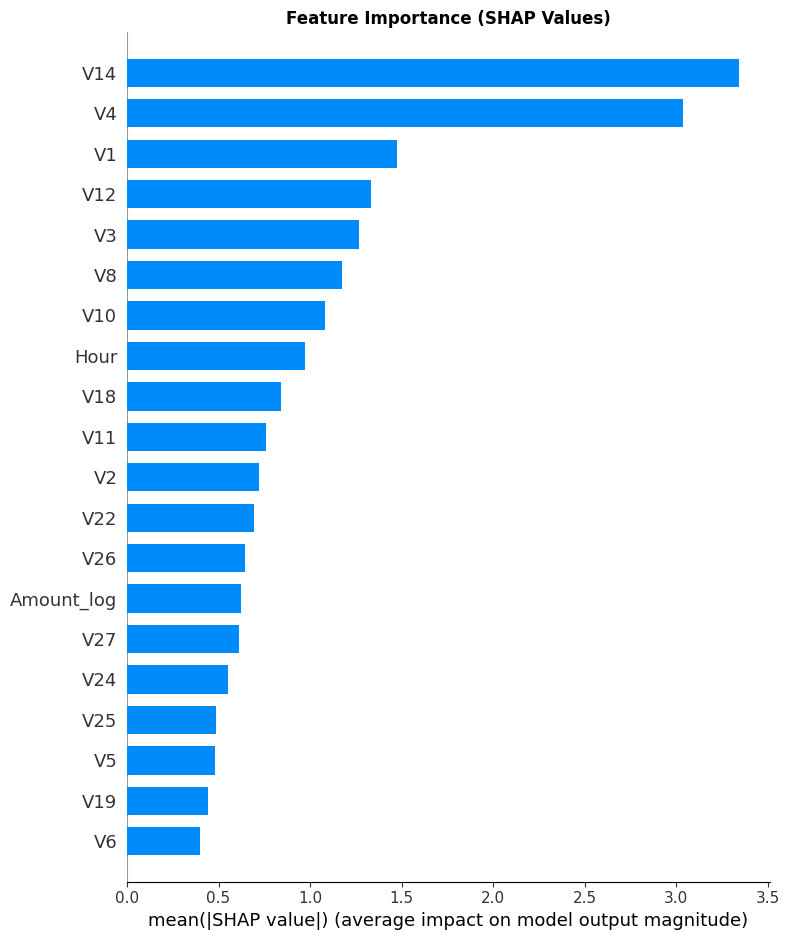


SHAP shows which features drove each fraud prediction
This makes the model explainable to non-technical stakeholders


In [28]:
# SHAP explains WHY the model flagged a transaction as fraud
# This is critical for production — regulators and business teams need explanations

xgb_model = final_pipeline.named_steps['model']

# Transform test data through pipeline steps (scaler only, no SMOTE on test)
X_test_scaled = final_pipeline.named_steps['scaler'].transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled_df[:500])  # sample for speed

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled_df[:500],
                  plot_type='bar', show=False)
plt.title('Feature Importance (SHAP Values)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSHAP shows which features drove each fraud prediction')
print('This makes the model explainable to non-technical stakeholders')

## Cell 12 — Export Model for Deployment

In [29]:
import pickle

MODEL_PATH = '/kaggle/working/fraud_model.pkl'
FEATURES_PATH = '/kaggle/working/feature_names.pkl'

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(final_pipeline, f)

with open(FEATURES_PATH, 'wb') as f:
    pickle.dump(list(X_train.columns), f)

print("Saved!")
print(os.listdir('/kaggle/working/'))

Saved!
['feature_names.pkl', 'mlflow.db', 'eda_plots.png', 'evaluation_plots.png', 'mlruns', 'fraud_model.pkl', '.virtual_documents', 'shap_importance.png']


In [30]:
# Export the full pipeline (scaler + SMOTE + model) as a single pickle
# NOTE: SMOTE is only used during .fit(), not during .predict()
# So the exported pipeline is safe for inference

MODEL_PATH = 'fraud_model.pkl'
FEATURES_PATH = 'feature_names.pkl'

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(final_pipeline, f)

with open(FEATURES_PATH, 'wb') as f:
    pickle.dump(list(X_train.columns), f)

print(f'Model exported to {MODEL_PATH} ✅')
print(f'Feature names exported to {FEATURES_PATH} ✅')

# Sanity check — reload and predict one sample
with open(MODEL_PATH, 'rb') as f:
    loaded_model = pickle.load(f)

sample = X_test.iloc[[0]]
prob = loaded_model.predict_proba(sample)[0][1]
label = 'FRAUD' if prob > 0.5 else 'LEGITIMATE'
print(f'\nSanity check — Sample prediction:')
print(f'  Fraud probability: {prob:.4f}')
print(f'  Prediction: {label}')
print(f'  Actual:     {"FRAUD" if y_test.iloc[0]==1 else "LEGITIMATE"}')
print('\n✅ Model ready for FastAPI deployment!')

Model exported to fraud_model.pkl ✅
Feature names exported to feature_names.pkl ✅

Sanity check — Sample prediction:
  Fraud probability: 0.0000
  Prediction: LEGITIMATE
  Actual:     LEGITIMATE

✅ Model ready for FastAPI deployment!


## Summary

| Step | What we did | Why it matters |
|------|-------------|----------------|
| EDA | Visualized class imbalance & distributions | Understand the problem before modeling |
| Feature Engineering | Log-transform Amount, Hour from Time | Reduce skew, add signal |
| Stratified Split | `stratify=y` in train_test_split | Preserve fraud ratio in both sets |
| ImbPipeline | SMOTE inside pipeline | **No data leakage** |
| Model Comparison | LR vs RF vs XGBoost | Pick winner on PR-AUC, not accuracy |
| Optuna Tuning | 30 trials, 3-fold Stratified CV | Systematic hyperparameter search |
| MLflow | Log all runs, params, metrics | Reproducible experiments |
| SHAP | Feature importance & explainability | Production requirement |
| Export | `fraud_model.pkl` | Ready for FastAPI |

**Next step:** Build FastAPI app using `fraud_model.pkl` → Dockerize → Deploy

In [31]:
import os

# Check where the files are
print("Files in /kaggle/working/:")
for f in os.listdir('/kaggle/working/'):
    print(f" - {f}")

Files in /kaggle/working/:
 - feature_names.pkl
 - mlflow.db
 - eda_plots.png
 - evaluation_plots.png
 - mlruns
 - fraud_model.pkl
 - .virtual_documents
 - shap_importance.png
